In [1]:
import torch
import torch.nn as nn
import math

import os

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
# 剩下所有业务代码

In [2]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()

        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]

In [3]:
import matplotlib.pyplot as plt

In [4]:
pe = PositionalEncoding(d_model=64)

In [5]:
pe_matrix = pe.pe[0, :50, :].numpy()

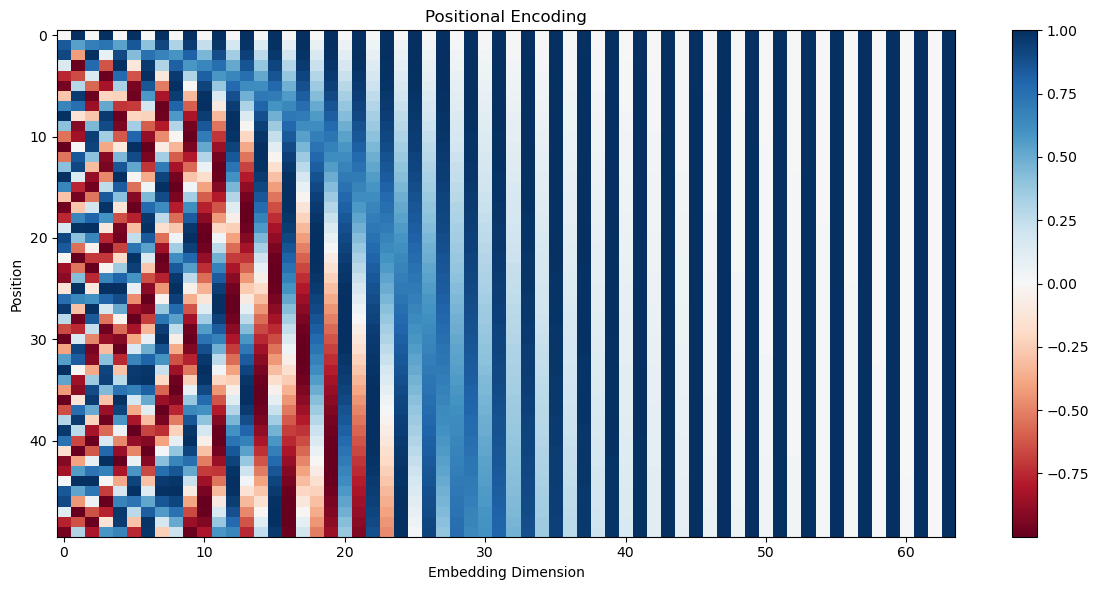

In [6]:
plt.figure(figsize=(12, 6))

plt.imshow(pe_matrix, aspect='auto', cmap='RdBu')
plt.xlabel('Embedding Dimension')
plt.ylabel('Position')
plt.title('Positional Encoding')
plt.colorbar()
plt.tight_layout()
plt.savefig('positional_encoding.png', dpi=100)

plt.show()